Contexte :

Ce projet vise à analyser et à segmenter les données de qualité de l'air (World Air Quality Index - WAQI) de différentes villes. L'objectif est de transformer des données brutes de concentration de polluants en informations stratégiques, permettant aux autorités d'identifier et de comparer les zones de pollution critique.

Objectif du Livrable :

Le livrable principal est un Dashboard Streamlit interactif et décisionnel qui présente :

•	Les indicateurs clés de la pollution.

•	La comparaison détaillée des villes et des polluants.

•	Une segmentation claire des villes en fonction de leur profil de risque.

•	Une lecture décisionnelle permettant l'allocation ciblée des ressources.


Algorithmes Imposés :

•	Nettoyage et Pré-traitement : Agrégation, Imputation.

•	Modélisation : Normalisation (StandardScaler) + K-Means.




In [1]:
import  numpy as np
import pandas as pd

### Chargement des Données.

In [39]:
data = pd.read_csv('city_day.csv')
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


### Agrégation et Nettoyage des Données 

Nettoyage et Structuration (Agrégation)
Les données initiales sont des enregistrements quotidiens de polluants par ville. 

L'unité d'analyse pour la segmentation étant la ville, une étape cruciale d'agrégation est nécessaire.

Regrouper les données par City et calculer la moyenne de chaque polluant.

Ceci donne un profil de pollution moyen et stable pour chaque ville sur l'ensemble de la période.

In [24]:

# 1. Colonnes pertinentes pour la segmentation :
colonnes_polluants = data.columns.drop(['City', 'Date', 'AQI', 'AQI_Bucket'])
#print(colonnes_polluants)
# Nous nous concentrons sur les concentrations de polluants pour la segmentation, pas l'AQI agrégé.

# 2. Agrégation par Ville : calcul de la MOYENNE de chaque polluant.
# Les NaN sont ignorés lors du calcul de la moyenne.
data_seg = data.groupby('City')[colonnes_polluants].mean().reset_index()
#print(data_seg.isnull().sum())
# 3. Gestion des valeurs manquantes après agrégation 
# Si une ville n'a jamais mesuré un certain polluant (ou n'a presque aucune donnée), sa moyenne sera NaN.
# Nous allons remplacer ces NaN par la moyenne nationale de ce polluant.
# Cette méthode permet de conserver toutes les villes sans biaiser significativement l'analyse par des valeurs extrêmes.

# a. Calcul de la moyenne nationale (des moyennes de villes)
means_fill = data_seg[colonnes_polluants].mean()

# b. Imputation : remplacer les NaN par cette moyenne nationale
data_seg.fillna(means_fill, inplace=True)

# 4. Vérification finale
print(f"Nombre de villes prêtes pour la segmentation (après imputation) : {data_seg.shape[0]}")
print(f"Vérification des NaN : {data_seg.isnull().sum().sum()} (doit être 0)")
data_seg.head()

Nombre de villes prêtes pour la segmentation (après imputation) : 26
Vérification des NaN : 0 (doit être 0)


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
0,Ahmedabad,67.854497,114.584029,22.428021,59.025496,47.366898,19.919840,22.193407,55.253733,39.155408,5.413807,27.740524,4.248341
1,Aizawl,17.130000,23.352857,9.408053,0.388496,12.610354,22.308938,0.283628,7.378053,3.707692,9.809286,10.247347,2.912956
2,Amaravati,37.773217,76.362020,4.436071,22.175748,15.380413,11.988493,0.627904,14.258341,38.115100,0.546416,1.877637,0.981613
3,Amritsar,55.468335,115.202599,18.727926,18.522116,35.648294,14.375556,0.551301,8.148917,22.416148,4.182290,3.036264,7.356062
4,Bengaluru,35.819828,83.243287,9.409136,27.995042,19.717092,21.977176,1.838634,5.519021,32.868086,3.222553,4.753194,2.912956


### Analyse Exploratoire et Pré-traitement

Analyse Descriptive des Polluants

In [25]:
data_seg.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,56.500147,102.813264,18.223413,23.445654,31.141291,19.919840,1.868334,13.992641,31.067125,4.835338,8.010683,2.912956
std,29.788973,47.897277,14.684435,14.518198,17.336111,13.066886,4.180701,10.910647,12.480433,7.348926,8.812101,1.539194
min,17.130000,23.352857,0.917092,0.388496,1.002202,2.813625,0.239675,3.184051,3.707692,0.009138,0.000359,0.008010
25%,35.353752,69.592079,9.244935,13.626813,19.508339,11.179545,0.639274,8.209713,25.795293,1.592814,2.057144,2.664909
50%,50.242592,104.382309,14.933159,22.776957,27.306570,18.370950,0.914857,10.054526,32.655951,3.717914,7.280062,2.912956
75%,64.186091,122.443712,22.994853,32.150301,43.138545,25.148075,1.604284,15.064235,37.166234,4.835338,8.265908,2.912956
max,123.498562,232.809229,71.771625,59.025496,68.412901,63.452612,22.193407,55.253733,59.851036,38.432563,38.658406,7.356062


Jeu de Données Final

•	Dimensions : 26 villes, 12 colonnes de polluants moyens.

•	État : Prêt pour la modélisation (aucune valeur manquante).


### Modélisation et Segmentation

Normalisation des Données (StandardScaler)

In [5]:
from sklearn.preprocessing import StandardScaler

Le K-Means est basé sur la distance euclidienne. 

Des variables avec de grandes échelles (comme PM2.5) domineraient le calcul de distance par rapport à des variables de faible échelle (comme NO2).

In [6]:
# Séparer les noms de villes des données numériques
Nom_city = data_seg['City']
X = data_seg.drop('City', axis=1)

# Appliquer le Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Remettre les données mises à l'échelle dans un DataFrame pour la lisibilité
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['City'] = Nom_city

df_scaled.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,City
0,0.388708,0.250617,0.292001,2.499240,0.954478,0.000000,4.957922,3.856620,0.660912,0.080274,2.283289,8.847690e-01,Ahmedabad
1,-1.347808,-1.691830,-0.612209,-1.619607,-1.090090,0.186457,-0.386559,-0.618257,-2.235600,0.690230,0.258844,-2.942344e-16,Aizawl
2,-0.641103,-0.563186,-0.957503,-0.089202,-0.927140,-0.619001,-0.302580,0.024835,0.575906,-0.595170,-0.709763,-1.279625e+00,Amaravati
3,-0.035323,0.263787,0.035037,-0.345845,0.265126,-0.432703,-0.321265,-0.546205,-0.706891,-0.090623,-0.575678,2.943811e+00,Amritsar
4,-0.707976,-0.416674,-0.612133,0.319563,-0.672033,0.160565,-0.007245,-0.792018,0.147161,-0.223805,-0.376982,-2.942344e-16,Bengaluru


### Clustering

Détermination du Nombre Optimal de Clusters avec la Méthode du Coude (Elbow Method)

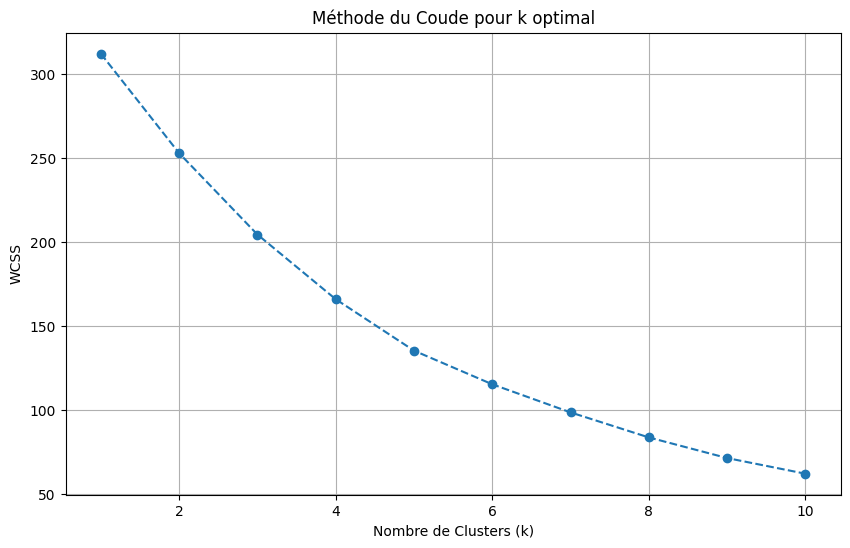

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Nous testons k de 1 à 10. Avec les villes
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled) 
    wcss.append(kmeans.inertia_) 

# Visualisation du coude
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Méthode du Coude pour k optimal')
plt.xlabel('Nombre de Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show() 

Application du K-Means

Le K-Means est appliqué au jeu de données normalisé avec le k choisi, assignant un numéro de cluster (0 à 4) à chaque ville.

In [31]:
# Pour k = 5
k_optimal = 5                                                                                                                                                                                                                 
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)

# Affectation des clusters à chaque ville
data_seg['Cluster'] = kmeans.fit_predict(X_scaled)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [32]:
data_seg.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,Cluster
0,Ahmedabad,67.854497,114.584029,22.428021,59.025496,47.366898,19.919840,22.193407,55.253733,39.155408,5.413807,27.740524,4.248341,2
1,Aizawl,17.130000,23.352857,9.408053,0.388496,12.610354,22.308938,0.283628,7.378053,3.707692,9.809286,10.247347,2.912956,1
2,Amaravati,37.773217,76.362020,4.436071,22.175748,15.380413,11.988493,0.627904,14.258341,38.115100,0.546416,1.877637,0.981613,1
3,Amritsar,55.468335,115.202599,18.727926,18.522116,35.648294,14.375556,0.551301,8.148917,22.416148,4.182290,3.036264,7.356062,1
4,Bengaluru,35.819828,83.243287,9.409136,27.995042,19.717092,21.977176,1.838634,5.519021,32.868086,3.222553,4.753194,2.912956,1


Visualisation et Caractérisation des Clusters

Pour visualiser les clusters dans un plan 2D, on va utiliser une méthode de réduction de dimension comme l'Analyse en Composantes Principales (PCA) sur X_scaled.
Réduction de Dimension (PCA) :

In [33]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
# Créer un DataFrame avec les composantes et le Cluster pour la visualisation (scatterplot)

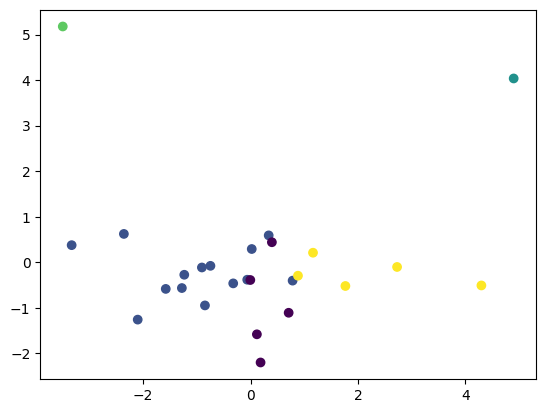

In [34]:
plt.scatter(components[:, 0], components[:, 1], c = data_seg['Cluster'].values)

### Création des Profils de Cluster

In [12]:
# 1. Ici on va utiliser le DataFrame qui contient les VRAIES VALEURS 

df_clusters = data_seg.copy()

# 2. Calcul des moyennes de polluants par cluster
profils_clusters = df_clusters.drop('City', axis=1).groupby('Cluster').mean()

# 3. Calcul du nombre de villes par cluster
Nb_clusters = df_clusters['Cluster'].value_counts().reset_index()
Nb_clusters.columns = ['Cluster', 'Nombre de Villes']

# 4. Affichage des profils
print("--- PROFIL DE CHAQUE CLUSTER (VALEURS MOYENNES RÉELLES) ---")
print(profils_clusters)
print("\n--- TAILLE DES CLUSTERS ---")
print(Nb_clusters)

--- PROFIL DE CHAQUE CLUSTER (VALEURS MOYENNES RÉELLES) ---
              PM2.5        PM10         NO        NO2        NOx        NH3  \
Cluster                                                                       
0         51.189337  119.223208  32.962179  15.442726  46.158878  10.288227   
1         41.607360   82.195802  11.086462  20.378952  22.194448  22.113253   
2         67.854497  114.584029  22.428021  59.025496  47.366898  19.919840   
3         30.823984   42.199170   0.917092   2.750956   1.002202   2.813625   
4        106.375123  153.900876  26.088451  37.058319  43.957560  26.831140   

                CO        SO2         O3    Benzene    Toluene    Xylene  
Cluster                                                                   
0         1.022214  21.919573  22.315136   2.978282   3.207443  2.331966  
1         0.952557   9.038311  31.320064   3.306957   5.154240  2.777865  
2        22.193407  55.253733  39.155408   5.413807  27.740524  4.248341  
3         0

Analyse et Interprétation des Clusters


1. Clusters avec les moyennes les plus élevées (Hauts Niveaux de Pollution)

Cluster 3 (1 ville) : Extrêmement élevé sur PM2.5 (106.37) et PM10 (153.90)

Profil Suggéré : Villes à Très Haut Risque Global / Pollution Particulaire Critique. 
C’est le cluster qui présente la concentration de poussières fines et grossières la plus dangereuse de l'échantillon.

Cluster 4 (5 villes) : Très élevé sur NO2 (59.02), SO2 (55.25), CO (22.19) et O3 (39.15)

Profil Suggéré : Villes à Risque Élevé / Pollution par Combustion Industrielle et Ozone. 
Ce groupe est marqué par des records sur les polluants gazeux et l'ozone de surface, 
ce qui indiquant une atmosphère chimiquement très active.

Cluster 0 (14 villes) : Élevé sur PM10 (119.22) et NO (32.96)

Profil Suggéré : Villes à Risque Élevé Généralisé / Pollution Mixte (Trafic et Particules). 
C'est le cluster le plus fréquent, représentant des zones urbaines denses avec une pollution particulaire et azotée soutenue.


3. Cluster avec les valeurs les plus faibles (Qualité de l'Air Supérieure)

Le Cluster 1 (5 villes) enregistre les valeurs les plus basses pour la majorité des polluants.

Il possède le PM2.5 le plus bas (41.60) et le PM10 le plus bas (82.19) parmi les groupes de villes habituels.

Il maintient des niveaux très faibles sur le CO (0.95), le Benzène (3.30) et le SO2 (9.03).

On peut donc confirmer que le Cluster 1 est le profil des "Villes Modérément Polluées / Villes à l'Air le Plus Pur" de votre étude.